In [1]:
import torch 
from torch import nn
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
data = pd.read_json('data/dataset.json', lines=True)
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)
data.drop(["article_link"], axis=1, inplace=True)

In [4]:
X = data["headline"]
y = data["is_sarcastic"]

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
bert_model = AutoModel.from_pretrained("google-bert/bert-base-uncased", num_labels=2)

In [7]:
class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [8]:
train_dataset = SarcasmDataset(X_train, y_train, tokenizer, max_length=64)
val_dataset = SarcasmDataset(X_val, y_val, tokenizer, max_length=64)
test_dataset = SarcasmDataset(X_test, y_test, tokenizer, max_length=64)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [9]:
batch = next(iter(train_dataloader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([16, 64])
torch.Size([16, 64])
torch.Size([16])


In [10]:
class SarcasmClassifier(nn.Module):
    def __init__(self, bert_model):
        super().__init__()
        self.bert = bert_model
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_output = outputs.last_hidden_state[:, 0]
        logits = self.classifier(cls_output)
        return logits

In [11]:
model = SarcasmClassifier(bert_model).to(device)

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [13]:
epochs = 3

train_loss_plot = []
val_loss_plot = []
train_acc_plot = []
val_acc_plot = []

for epoch in range(epochs):

    train_loss = 0
    train_correct = 0

    val_loss = 0
    val_correct = 0

    model.train()

    for batch in train_dataloader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_dataloader)
    train_acc = train_correct / len(train_dataset)

    train_loss_plot.append(train_loss)
    train_acc_plot.append(train_acc)

  
    # Validation
    model.eval()

    with torch.no_grad():

        for batch in val_dataloader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_dataloader)
    val_acc = val_correct / len(val_dataset)

    val_loss_plot.append(val_loss)
    val_acc_plot.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

Epoch 1/3 | Train Loss: 0.2617 | Train Acc: 0.8898 | Val Loss: 0.1841 | Val Acc: 0.9214
Epoch 2/3 | Train Loss: 0.1011 | Train Acc: 0.9634 | Val Loss: 0.3457 | Val Acc: 0.8864
Epoch 3/3 | Train Loss: 0.0442 | Train Acc: 0.9855 | Val Loss: 0.2447 | Val Acc: 0.9316


In [14]:
test_loss = 0
test_correct = 0

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for batch in test_dataloader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        test_correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_dataloader)
test_acc = test_correct / len(test_dataset)

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Test Loss: 0.2464 | Test Acc: 0.9279


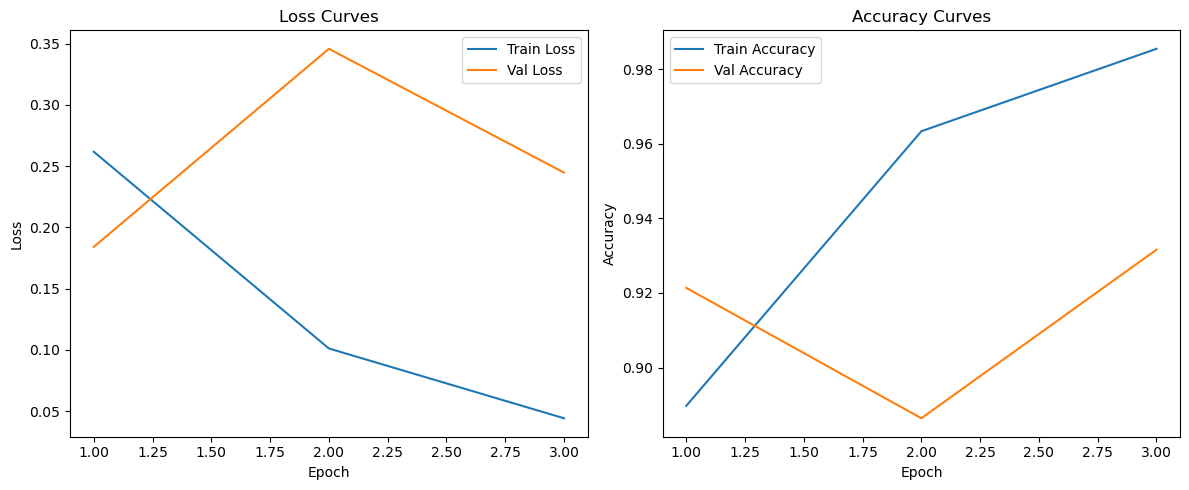

In [15]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_loss_plot)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, train_loss_plot, label="Train Loss")
plt.plot(epochs_range, val_loss_plot, label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, train_acc_plot, label="Train Accuracy")
plt.plot(epochs_range, val_acc_plot, label="Val Accuracy")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

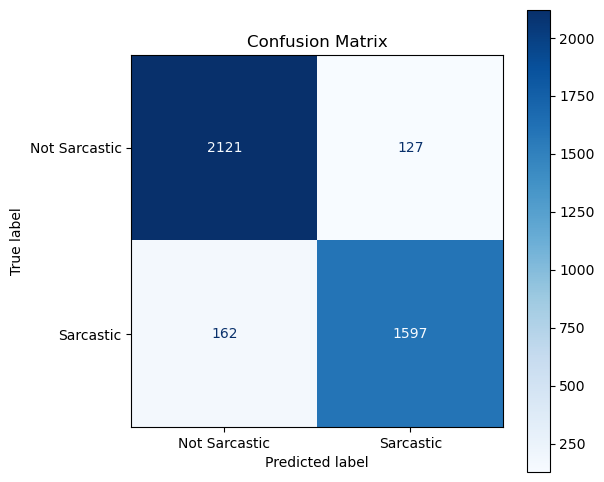

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Sarcastic","Sarcastic"]
)

disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=["Not Sarcastic","Sarcastic"]))

               precision    recall  f1-score   support

Not Sarcastic       0.93      0.94      0.94      2248
    Sarcastic       0.93      0.91      0.92      1759

     accuracy                           0.93      4007
    macro avg       0.93      0.93      0.93      4007
 weighted avg       0.93      0.93      0.93      4007



In [18]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model.state_dict(), "models/sarcasm_classifier.pth")